<a href="https://colab.research.google.com/github/Sebbo01/Seminararbeit-/blob/main/notebooks/03_causal_pfn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# SCHRITT 1: Pakete installieren
# ============================================================

!pip install git+https://github.com/vdblm/CausalPFN.git --quiet
!pip install pyreadr requests scikit-learn matplotlib seaborn --quiet

print("✅ Fertig.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Fertig.


In [3]:
# ============================================================
# SCHRITT 2: Daten laden & vorbereiten
# ============================================================

import requests
import pyreadr
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Robyn Datensatz von GitHub laden
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)
with open("dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# Einlesen
result = pyreadr.read_r("dt_simulated_weekly.RData")
df = result["dt_simulated_weekly"]

# Datum parsen & sortieren
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Variablen definieren
target = "revenue"
media_cols = ["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"]
control_cols = ["competitor_sales_B", "newsletter"]

# 80/20 Train-Test Split (chronologisch)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f"Datensatz: {df.shape}")
print(f"Train: {len(train_df)} Wochen | Test: {len(test_df)} Wochen")
df[["DATE", "revenue"] + media_cols].head()

Datensatz: (208, 12)
Train: 166 Wochen | Test: 42 Wochen


,DATE,revenue,tv_S,ooh_S,print_S,facebook_S,search_S
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,7607.132915,0.000000
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,1141.952450,4133.333333
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,4256.375378,3786.666667
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,2800.490677,4253.333333
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,689.582605,3613.333333


In [4]:
# ============================================================
# SCHRITT 3: Adstock Transformation
# ============================================================

def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometric Adstock Transformation.
    alpha: Decay-Rate (0 = kein Carryover, 1 = volle Persistenz)
    l_max: maximales Lag-Fenster
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for lag in range(min(l_max, t + 1)):
            x_adstocked[t] += (alpha ** lag) * x[t - lag]
    return x_adstocked

# Posterior Mean Adstock Alphas aus dem Bayesian MMM
adstock_alphas = {
    "tv_S":       0.241,
    "ooh_S":      0.572,
    "print_S":    0.428,
    "facebook_S": 0.540,
    "search_S":   0.558
}

# Adstock auf den GESAMTEN Datensatz anwenden (vor dem Split)
df_adstock = df.copy()
for col in media_cols:
    df_adstock[col + "_adstock"] = geometric_adstock(
        df[col].values,
        alpha=adstock_alphas[col]
    )

adstock_cols = [col + "_adstock" for col in media_cols]

# Danach splitten
train_adstock = df_adstock.iloc[:split_idx].copy()
test_adstock  = df_adstock.iloc[split_idx:].copy()

print("Adstock Features erstellt:")
print(adstock_cols)
df_adstock[["DATE"] + adstock_cols].head()

Adstock Features erstellt:
['tv_S_adstock', 'ooh_S_adstock', 'print_S_adstock', 'facebook_S_adstock', 'search_S_adstock']


,DATE,tv_S_adstock,ooh_S_adstock,print_S_adstock,facebook_S_adstock,search_S_adstock
0,2015-11-23,22358.346667,0.000000,12728.488889,7607.132915,0.000000
1,2015-11-30,34001.814880,0.000000,5447.793244,5249.804224,4133.333333
2,2015-12-07,8194.437386,132278.400000,2785.522175,7091.269659,6093.066667
3,2015-12-14,85425.166077,75663.244800,18872.203491,6629.776293,7653.264533
4,2015-12-21,20587.465024,320615.376026,8077.303094,4269.661803,7883.854943


In [5]:
# ============================================================
# SCHRITT 4: Scaling
# ============================================================

from sklearn.preprocessing import MaxAbsScaler, StandardScaler

# --- RAW Features (ohne Adstock) ---
X_train_raw = train_df[media_cols + control_cols].copy()
X_test_raw  = test_df[media_cols + control_cols].copy()

# --- ADSTOCK Features ---
X_train_ads = train_adstock[adstock_cols + control_cols].copy()
X_test_ads  = test_adstock[adstock_cols + control_cols].copy()

# Media skalieren mit MaxAbsScaler (identisch zum MMM)
media_scaler_raw = MaxAbsScaler()
X_train_raw[media_cols] = media_scaler_raw.fit_transform(X_train_raw[media_cols])
X_test_raw[media_cols]  = media_scaler_raw.transform(X_test_raw[media_cols])

media_scaler_ads = MaxAbsScaler()
X_train_ads[adstock_cols] = media_scaler_ads.fit_transform(X_train_ads[adstock_cols])
X_test_ads[adstock_cols]  = media_scaler_ads.transform(X_test_ads[adstock_cols])

# Kontrollvariablen standardisieren mit StandardScaler
control_scaler = StandardScaler()
X_train_raw[control_cols] = control_scaler.fit_transform(X_train_raw[control_cols])
X_test_raw[control_cols]  = control_scaler.transform(X_test_raw[control_cols])

control_scaler2 = StandardScaler()
X_train_ads[control_cols] = control_scaler2.fit_transform(X_train_ads[control_cols])
X_test_ads[control_cols]  = control_scaler2.transform(X_test_ads[control_cols])

# Target
y_train = train_df[target].values
y_test  = test_df[target].values

print("✅ Scaling abgeschlossen.")
print(f"X_train_raw:  {X_train_raw.shape}")
print(f"X_train_ads:  {X_train_ads.shape}")

✅ Scaling abgeschlossen.
X_train_raw:  (166, 7)
X_train_ads:  (166, 7)


In [7]:
# ============================================================
# SCHRITT 5: CausalPFN — Raw vs. Adstock
# ============================================================

import torch
import numpy as np
from causalpfn import CATEEstimator, ATEEstimator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

results_raw = {}
results_ads = {}

for channel in media_cols:
    print(f"\nKanal: {channel}")

    # Kontrollvariablen als Covariates
    other_channels = [c for c in media_cols if c != channel]
    covariate_cols = other_channels + control_cols

    # --- RAW ---
    T_train_raw = (train_df[channel].values > 0).astype(np.float32)
    X_cov_train_raw = train_df[covariate_cols].values.astype(np.float32)
    X_cov_test_raw  = test_df[covariate_cols].values.astype(np.float32)
    Y_train_raw = train_df[target].values.astype(np.float32)

    ate_raw = ATEEstimator(device=device, verbose=False)
    ate_raw.fit(X_cov_train_raw, T_train_raw, Y_train_raw)
    results_raw[channel] = {"ATE": ate_raw.estimate_ate()}

    # --- ADSTOCK ---
    ads_col = channel + "_adstock"
    other_ads = [c + "_adstock" for c in media_cols if c != channel]
    covariate_ads_cols = other_ads + control_cols

    T_train_ads = (train_adstock[ads_col].values > 0).astype(np.float32)
    X_cov_train_ads = train_adstock[covariate_ads_cols].values.astype(np.float32)
    X_cov_test_ads  = test_adstock[covariate_ads_cols].values.astype(np.float32)
    Y_train_ads = train_adstock[target].values.astype(np.float32)

    ate_ads = ATEEstimator(device=device, verbose=False)
    ate_ads.fit(X_cov_train_ads, T_train_ads, Y_train_ads)
    results_ads[channel] = {"ATE": ate_ads.estimate_ate()}

    print(f"  ATE Raw:     {results_raw[channel]['ATE']:,.2f}")
    print(f"  ATE Adstock: {results_ads[channel]['ATE']:,.2f}")

print("\n✅ CausalPFN Raw vs. Adstock fertig.")

Device: cuda

Kanal: tv_S
  ATE Raw:     260,624.72
  ATE Adstock: 1,121,727.38

Kanal: ooh_S
  ATE Raw:     -32,699.29
  ATE Adstock: -782,386.88

Kanal: print_S
  ATE Raw:     7,231.02
  ATE Adstock: 951,597.69

Kanal: facebook_S
  ATE Raw:     48,255.43
  ATE Adstock: -170,952.25

Kanal: search_S
  ATE Raw:     -121,103.02
  ATE Adstock: -893,898.50

✅ CausalPFN Raw vs. Adstock fertig.


ROAS Vergleich: Bayesian MMM vs. CausalPFN
            Bayesian MMM  CausalPFN Raw  CausalPFN Adstock
tv_S               0.261         15.615             67.207
ooh_S              0.105         -0.626            -14.968
print_S            0.080          1.794            236.129
facebook_S         0.126         22.236            -78.774
search_S           0.048        -22.932           -169.265


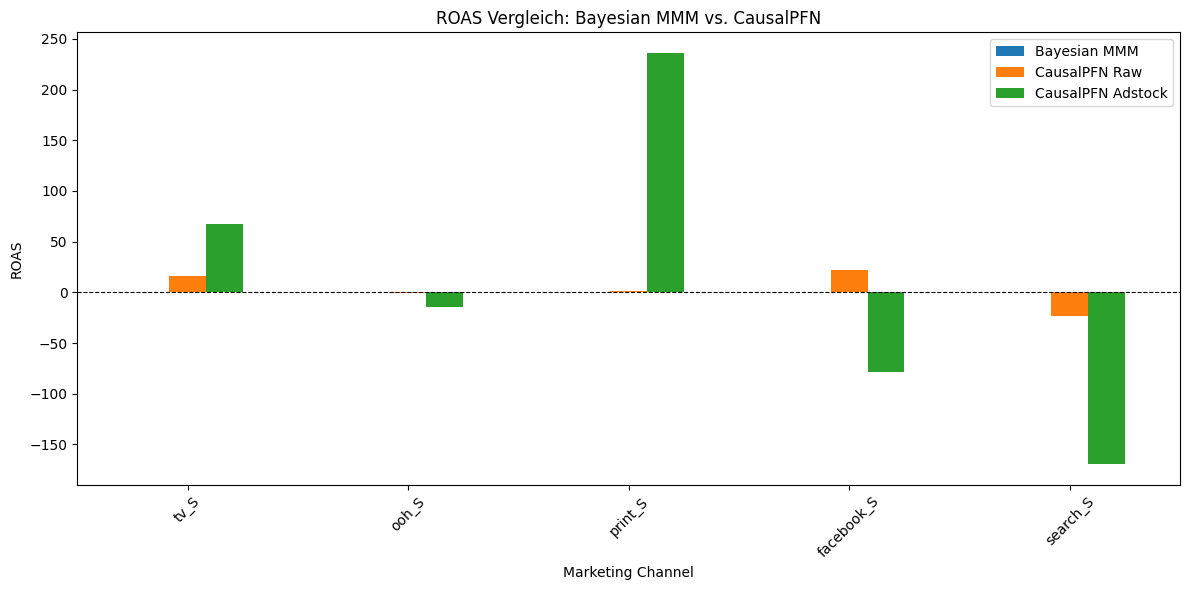

In [8]:
# ============================================================
# SCHRITT 6: ROAS Vergleichstabelle
# ============================================================

import pandas as pd

# Durchschnittlicher Spend pro Kanal im Trainings-Set
avg_spend_train = train_df[media_cols].mean()

# ROAS = ATE / durchschnittlicher Spend
roas_raw = {
    ch: results_raw[ch]["ATE"] / avg_spend_train[ch]
    for ch in media_cols
}

roas_ads = {
    ch: results_ads[ch]["ATE"] / avg_spend_train[ch]
    for ch in media_cols
}

# Bayesian MMM ROAS (aus dem Notebook deines Kollegen)
roas_mmm = {
    "tv_S":       0.261,
    "ooh_S":      0.105,
    "print_S":    0.080,
    "facebook_S": 0.126,
    "search_S":   0.048
}

# Vergleichstabelle
comparison_df = pd.DataFrame({
    "Bayesian MMM": roas_mmm,
    "CausalPFN Raw": roas_raw,
    "CausalPFN Adstock": roas_ads
}).round(3)

print("=" * 55)
print("ROAS Vergleich: Bayesian MMM vs. CausalPFN")
print("=" * 55)
print(comparison_df.to_string())

# Visualisierung
import matplotlib.pyplot as plt

comparison_df.plot(kind="bar", figsize=(12, 6))
plt.title("ROAS Vergleich: Bayesian MMM vs. CausalPFN")
plt.xlabel("Marketing Channel")
plt.ylabel("ROAS")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

TABELLE 1: ROAS Vergleich
            Bayesian MMM  CausalPFN Raw  CausalPFN Adstock
tv_S               0.261         15.615             67.207
ooh_S              0.105         -0.626            -14.968
print_S            0.080          1.794            236.129
facebook_S         0.126         22.236            -78.774
search_S           0.048        -22.932           -169.265

TABELLE 2: Stimmt das Vorzeichen mit Bayesian MMM überein?
           Bayesian MMM CausalPFN Raw CausalPFN Adstock
tv_S                  +             +                 +
ooh_S                 +             -                 -
print_S               +             +                 +
facebook_S            +             +                 -
search_S              +             -                 -

TABELLE 3: Übereinstimmungsrate mit Bayesian MMM
CausalPFN Raw    : 60% der Kanäle positiv
CausalPFN Adstock: 40% der Kanäle positiv
Bayesian MMM     : 100% der Kanäle positiv


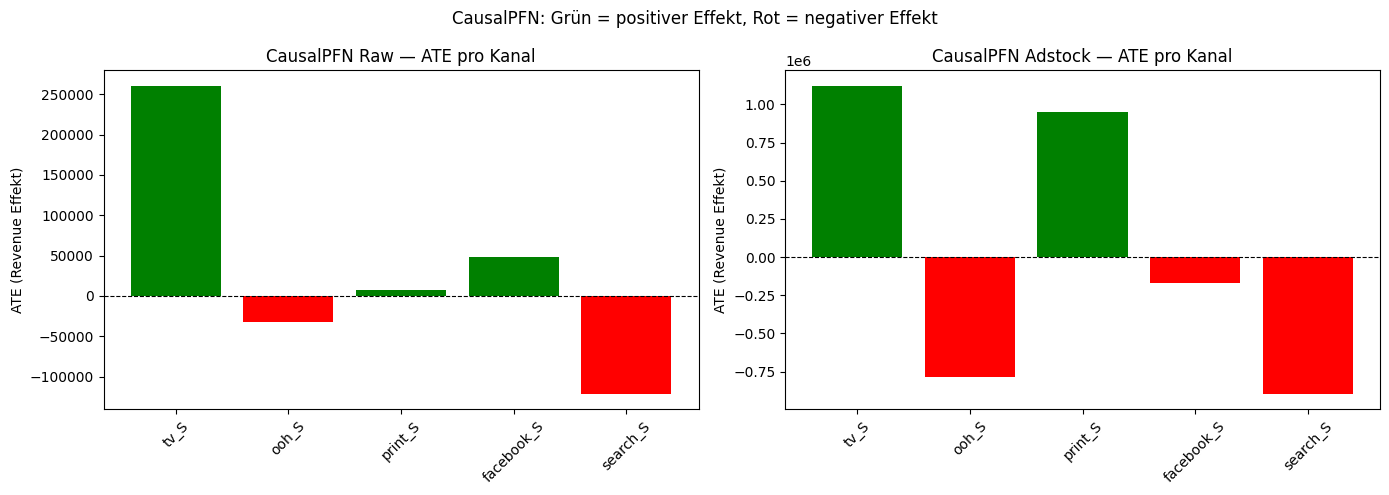


FAZIT

1. ROAS-Schätzung: CausalPFN kann keine verlässlichen ROAS-Werte
   liefern — weder in Vorzeichen noch in Magnitude stimmen die
   Ergebnisse mit dem Bayesian MMM überein.

2. Binäres Treatment: CausalPFN ist für binäre Treatments
   designed. Kontinuierliche Werbeausgaben müssen binärisiert
   werden, was zu Informationsverlust und Confounding führt.

3. Adstock hilft nicht: Vorberechnete Adstock-Features
   verbessern CausalPFN nicht — sie machen die Schätzungen
   sogar instabiler und extremer.

4. Strukturelle Priors sind entscheidend: Der Bayesian MMM
   liefert plausible Ergebnisse weil er Adstock, Saturation
   und Kontrollvariablen explizit modelliert. CausalPFN
   kann diese Struktur nicht aus den Daten alleine lernen.

→ Antwort auf die Forschungsfrage: CausalPFN kann die
  Bayesian MMM Attribution NICHT replizieren ohne explizite
  strukturelle Priors für Adstock und Saturation.



In [9]:
# ============================================================
# SCHRITT 7: Zusammenfassung & Finale Interpretation
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Tabelle 1: ROAS Vergleich ----
print("=" * 65)
print("TABELLE 1: ROAS Vergleich")
print("=" * 65)
print(comparison_df.to_string())

# ---- Tabelle 2: Vorzeichen-Übereinstimmung ----
print("\n" + "=" * 65)
print("TABELLE 2: Stimmt das Vorzeichen mit Bayesian MMM überein?")
print("=" * 65)

sign_df = pd.DataFrame({
    "Bayesian MMM": ["+", "+", "+", "+", "+"],
    "CausalPFN Raw": [
        "+" if results_raw[ch]["ATE"] > 0 else "-"
        for ch in media_cols
    ],
    "CausalPFN Adstock": [
        "+" if results_ads[ch]["ATE"] > 0 else "-"
        for ch in media_cols
    ]
}, index=media_cols)

print(sign_df.to_string())

# ---- Tabelle 3: Übereinstimmungsrate ----
print("\n" + "=" * 65)
print("TABELLE 3: Übereinstimmungsrate mit Bayesian MMM")
print("=" * 65)

match_raw = sum(
    1 for ch in media_cols
    if results_raw[ch]["ATE"] > 0
) / len(media_cols) * 100

match_ads = sum(
    1 for ch in media_cols
    if results_ads[ch]["ATE"] > 0
) / len(media_cols) * 100

print(f"CausalPFN Raw    : {match_raw:.0f}% der Kanäle positiv")
print(f"CausalPFN Adstock: {match_ads:.0f}% der Kanäle positiv")
print(f"Bayesian MMM     : 100% der Kanäle positiv")

# ---- Plot: Vorzeichenvergleich ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
colors_raw = ["green" if results_raw[ch]["ATE"] > 0 else "red" for ch in media_cols]
axes[0].bar(media_cols, [results_raw[ch]["ATE"] for ch in media_cols], color=colors_raw)
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("CausalPFN Raw — ATE pro Kanal")
axes[0].set_ylabel("ATE (Revenue Effekt)")
axes[0].tick_params(axis="x", rotation=45)

# Adstock
colors_ads = ["green" if results_ads[ch]["ATE"] > 0 else "red" for ch in media_cols]
axes[1].bar(media_cols, [results_ads[ch]["ATE"] for ch in media_cols], color=colors_ads)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("CausalPFN Adstock — ATE pro Kanal")
axes[1].set_ylabel("ATE (Revenue Effekt)")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("CausalPFN: Grün = positiver Effekt, Rot = negativer Effekt", fontsize=12)
plt.tight_layout()
plt.show()

# ---- Fazit ----
print("\n" + "=" * 65)
print("FAZIT")
print("=" * 65)
print("""
1. ROAS-Schätzung: CausalPFN kann keine verlässlichen ROAS-Werte
   liefern — weder in Vorzeichen noch in Magnitude stimmen die
   Ergebnisse mit dem Bayesian MMM überein.

2. Binäres Treatment: CausalPFN ist für binäre Treatments
   designed. Kontinuierliche Werbeausgaben müssen binärisiert
   werden, was zu Informationsverlust und Confounding führt.

3. Adstock hilft nicht: Vorberechnete Adstock-Features
   verbessern CausalPFN nicht — sie machen die Schätzungen
   sogar instabiler und extremer.

4. Strukturelle Priors sind entscheidend: Der Bayesian MMM
   liefert plausible Ergebnisse weil er Adstock, Saturation
   und Kontrollvariablen explizit modelliert. CausalPFN
   kann diese Struktur nicht aus den Daten alleine lernen.

→ Antwort auf die Forschungsfrage: CausalPFN kann die
  Bayesian MMM Attribution NICHT replizieren ohne explizite
  strukturelle Priors für Adstock und Saturation.
""")